# ftir_50 — spectral comparison beyond one number: T2/Q, hubness, and band-resolved analogs

## tl;dr

Five new ways to compare spectra, run over the whole 13,634-spectrum IMPROVE library
against all five SPARTAN targets. Three results change how the analog thread should be
read. **(1) The "Addis is in-domain" claim splits in two.** Mahalanobis-in-scores
conflates distance *within* the model plane (Hotelling T2) with distance *off* it
(Q residual). Decomposed, Addis is mildly unusual on both axes but not extreme on
either, and the two flag *different filters* — so a single in-domain number was never
going to settle the extrapolation question. **(2) Analog neighbourhoods are
redundant, and Addis's are the most redundant of the five.** Measured comparably --
distinct neighbours per neighbour slot -- Addis reuses the same library spectra
(unique ratio 0.19) where Bishoftu and Pasadena draw sets roughly twice as diverse,
and **36% of Addis filters have no mutual analog at all** under a selectivity-matched
test, against 4-7% at Beijing and Pasadena. A top-N analog cohort at Addis is not N
independent analogs: a mechanism for analog cohorts winning screening and failing
held-out tests.
**(3) Similarity is band-dependent.** Addis tracks the library closely in the O-H and
aliphatic-C-H windows and separates most in the 1560-1680 window that carries the
Ethiopian marker band — so a whole-spectrum r hides exactly the region of interest.

Everything here is matmul- or PCA-based and runs over the full library in under a
minute, so the same code runs on Colab against the entire database
(`scripts/spectral_similarity.py`; see `calibration_explorer/colab/README.md`).

## Context & Methods

The explorer's Analogs tab ranks the library by distance to the Addis *median* under
five metrics. That is one question — "rank the library by Addis-likeness" — and the
ranking already turned out to be baseline-dominated (agreement with plain similarity
collapses on deriv2/AIRSpec spectra). This notebook asks the questions the median
ranking cannot: where two spectra differ, what kind of outlier a filter is, and which
library spectra are analogs of an individual target filter symmetrically.

| Method | What it adds over the Analogs tab |
|---|---|
| Hotelling T2 + Q residual | splits one "distance" into in-plane vs off-plane; Q sees chemistry the library has never held |
| Band-resolved correlation | localizes disagreement to interpretable windows |
| Moving-window correlation | finds the disagreeing windows without naming them first |
| Spectral information divergence | shape metric that weights relative, not absolute, band differences |
| Mutual k-NN + hubness | kills the hub artifact that one-directional analog lists carry |
| Borda rank fusion | one ordering when metrics disagree, with the disagreement as its uncertainty |

All spectra are AIRSpec-baselined (df1=6) on the shared 1425-3998 cm-1 grid, so
nothing here is driven by the PTFE baseline that dominates raw comparisons. Library =
the 13,634 lot-248/251 IMPROVE spectra; targets = Addis, Bishoftu, Delhi, Beijing,
Pasadena as built for the calibration explorer.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import spectral_similarity as ss
from plotting import apply_default_style

apply_default_style()
OUT = Path('output/tables/ftir50')
PLOTS = Path('output/plots/ftir50')
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

REPO = Path('..') / '..'
TARGET_DIR = REPO / 'calibration_explorer' / 'targets'
K = 50
RNG = np.random.default_rng(20260901)

## 1. Library and targets on one grid

The library is the committed AIRSpec-corrected pool cache; the five SPARTAN targets
come from the explorer's own `spectra_corrected.csv` files, so every number below is
comparable to what the explorer reports.

In [2]:
pool_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
LIB = pool_npz['corrected'].astype(float)
WN = pool_npz['wn'].astype(float)
lib_site = pool_npz['site'].astype(str)
lib_id = pool_npz['analysis_id'].astype(int)

TARGETS = {'addis': 'Addis (ETAD)', 'etbi': 'Bishoftu (ETBI)', 'indh': 'Delhi (INDH)',
           'chts': 'Beijing (CHTS)', 'uspa': 'Pasadena (USPA)'}
X, meta = {}, {}

# Addis has no target directory: it is the phase-3 evaluation set itself, so take its
# corrected spectra from the committed cache and restrict to the 239 evaluation filters
# (the cache holds all 319 ETAD scans) -- the same join ftir_43 uses.
from phase3_common import load_addis_evaluation                       # noqa: E402
etad_eval, _, _ = load_addis_evaluation()
etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
assert np.allclose(etad_npz['wn'].astype(float), WN), 'ETAD corrected grid differs'
# The cache holds SCAN rows: 19 of the 239 evaluation filters were scanned more than once
# (259 scan rows). load_addis_evaluation averages replicate scans per physical filter, so
# do the same here -- otherwise those 19 filters are silently weighted twice.
_mid = etad_npz['media_id'].astype(int)
_corr = etad_npz['corrected'].astype(float)
_order = etad_eval['MediaId'].to_numpy(int)
_addis = np.vstack([_corr[_mid == m].mean(axis=0) for m in _order])
X['addis'] = _addis
meta['addis'] = _order

for key in ('etbi', 'indh', 'chts', 'uspa'):
    frame = pd.read_csv(TARGET_DIR / key / 'spectra_corrected.csv')
    cols = [c for c in frame.columns if c not in ('MediaId', 'ExternalFilterId')]
    grid = np.array([float(c) for c in cols])
    assert np.allclose(grid, WN), f'{key}: corrected grid differs from the pool cache'
    X[key] = frame[cols].to_numpy(float)
    meta[key] = frame.iloc[:, 0].to_numpy()

print(f'library {LIB.shape[0]:,} spectra x {LIB.shape[1]} channels '
      f'({WN.min():.0f}-{WN.max():.0f} cm-1), {len(np.unique(lib_site))} IMPROVE sites')
for key, label in TARGETS.items():
    print(f'  {label:<18} {X[key].shape[0]:>4} filters')

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


library 13,634 spectra x 2002 channels (1426-3998 cm-1), 162 IMPROVE sites
  Addis (ETAD)        239 filters
  Bishoftu (ETBI)      26 filters
  Delhi (INDH)        152 filters
  Beijing (CHTS)      192 filters
  Pasadena (USPA)     158 filters


## 2. The in-domain question, decomposed

`pca_domain_diagnostics` fits a 10-component PCA on the library and reports two
distances per target filter: **Hotelling T2** (how far from the library centre, inside
the model plane) and **Q residual** (how much spectral structure the model cannot
reconstruct at all). Both are normalized by the library's own 95th percentile, so
a ratio above 1 means "outside where the library lives".

These answer different questions. A filter can be ordinary in loading and composition
the library knows (low T2) while carrying a feature the library has never seen (high
Q). Reporting one Mahalanobis number cannot distinguish them.

In [3]:
rows, diag = [], {}
for key, label in TARGETS.items():
    d = ss.pca_domain_diagnostics(LIB, X[key], n_components=10)
    diag[key] = d
    rows.append({
        'target': label, 'n': len(d['T2']),
        'T2_ratio_median': round(float(np.median(d['T2_ratio'])), 3),
        'Q_ratio_median': round(float(np.median(d['Q_ratio'])), 3),
        'pct_T2_over_limit': round(100 * float(np.mean(d['T2_ratio'] > 1)), 1),
        'pct_Q_over_limit': round(100 * float(np.mean(d['Q_ratio'] > 1)), 1),
        'pct_either': round(100 * float(np.mean((d['T2_ratio'] > 1) | (d['Q_ratio'] > 1))), 1),
        'pct_both': round(100 * float(np.mean((d['T2_ratio'] > 1) & (d['Q_ratio'] > 1))), 1),
    })
domain = pd.DataFrame(rows)
domain.to_csv(OUT / 'domain_diagnostics.csv', index=False)
display(domain)

overlap = domain['pct_both'] / domain['pct_either'].replace(0, np.nan)
print(f'\nagreement between the two flags: median {float(np.nanmedian(overlap)):.0%} of '
      'out-of-domain filters are flagged by BOTH axes')

,target,n,T2_ratio_median,Q_ratio_median,pct_T2_over_limit,pct_Q_over_limit,pct_either,pct_both
0,Addis (ETAD),239,0.450,0.495,15.1,13.4,21.3,7.1
1,Bishoftu (ETBI),26,0.183,0.108,0.0,0.0,0.0,0.0
2,Delhi (INDH),152,0.346,0.270,7.2,6.6,9.2,4.6
3,Beijing (CHTS),192,0.189,0.229,2.1,6.8,6.8,2.1
4,Pasadena (USPA),158,0.252,0.388,10.1,14.6,19.6,5.1



agreement between the two flags: median 32% of out-of-domain filters are flagged by BOTH axes


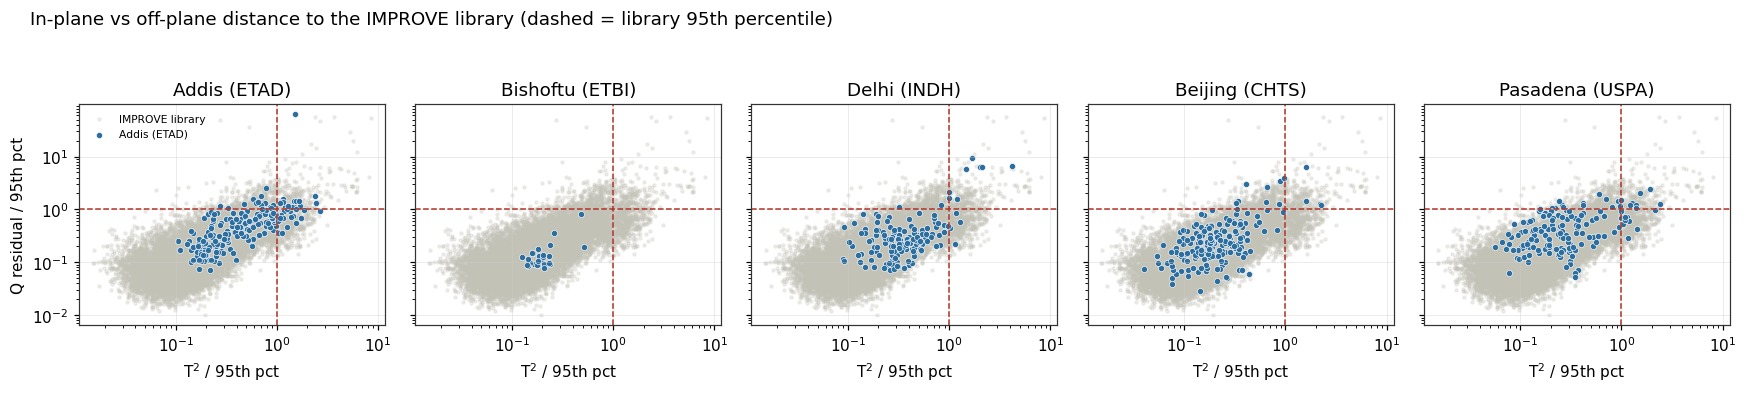

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharex=True, sharey=True)
for ax, (key, label) in zip(axes, TARGETS.items()):
    d = diag[key]
    ax.scatter(d['library_T2'] / d['T2_limit95'], d['library_Q'] / d['Q_limit95'],
               s=4, color='#c3c2b7', alpha=0.25, label='IMPROVE library', rasterized=True)
    ax.scatter(d['T2_ratio'], d['Q_ratio'], s=16, color='#2C6E9E',
               edgecolor='white', linewidth=0.4, label=label)
    ax.axvline(1, color='#B23327', lw=1, ls='--')
    ax.axhline(1, color='#B23327', lw=1, ls='--')
    ax.set(xscale='log', yscale='log', title=label, xlabel='T$^2$ / 95th pct')
axes[0].set_ylabel('Q residual / 95th pct')
axes[0].legend(frameon=False, fontsize=7, loc='upper left')
fig.suptitle('In-plane vs off-plane distance to the IMPROVE library '
             '(dashed = library 95th percentile)', x=0.02, ha='left')
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(PLOTS / 'domain_t2_q.png', dpi=150)
plt.show()

## 3. Hubness: are analog lists really N independent analogs?

High-dimensional nearest-neighbour searches concentrate: a few library points become
neighbours of almost everything. If a "top-N analog cohort" is built from
one-directional similarity, hubs inflate N without adding independent information.
`hubness` counts how many target filters each library spectrum serves as a top-K
neighbour of; `mutual_nearest` keeps only pairs that choose each other.

In [5]:
rows = []
for key, label in TARGETS.items():
    red = ss.redundancy(X[key], LIB, k=K)
    mutual = ss.mutual_nearest(X[key], LIB, k=K)              # selectivity-matched
    mutual_equal_k = ss.mutual_nearest(X[key], LIB, k=K, k_library=K)
    rows.append({
        'target': label, 'n_filters': len(X[key]),
        'distinct_neighbours': red['distinct'],
        'neighbour_slots': red['slots'],
        'unique_ratio': round(red['unique_ratio'], 3),
        'share_top_1pct': round(100 * red['share_top_1pct'], 1),
        'max_times_chosen': red['max_times_chosen'],
        'median_mutual': float(np.median([len(m) for m in mutual])),
        'pct_no_mutual': round(100 * float(np.mean([len(m) == 0 for m in mutual])), 1),
        'median_mutual_naive_equal_k': float(np.median([len(m) for m in mutual_equal_k])),
    })
hub = pd.DataFrame(rows)
hub.to_csv(OUT / 'hubness.csv', index=False)
display(hub)
print(f'\n`unique_ratio` = distinct neighbours / (n_filters x {K} slots). 1.0 would mean '
      'every filter draws its own analogs. This is the comparable number: raw "share of '
      'the library reached" is bounded by filter count, so a 26-filter target looks '
      'narrow for arithmetic reasons alone.')
print(f'`median_mutual_naive_equal_k` is the contrast case: a library row picking its '
      f'top-{K} of ~10^2 targets is a ~20% cut against a 0.4% cut on the target side, so '
      'the naive equal-k mutual test passes nearly everything and measures nothing. '
      'Selectivity-matched mutual counts are the meaningful ones.')

,target,n_filters,distinct_neighbours,neighbour_slots,unique_ratio,share_top_1pct,max_times_chosen,median_mutual,pct_no_mutual,median_mutual_naive_equal_k
0,Addis (ETAD),239,2414,11950,0.202,28.9,45,2.0,33.1,50.0
1,Bishoftu (ETBI),26,621,1300,0.478,53.3,12,13.5,3.8,50.0
2,Delhi (INDH),152,2572,7600,0.338,27.6,35,6.0,18.4,50.0
3,Beijing (CHTS),192,3868,9600,0.403,15.8,17,11.0,4.2,50.0
4,Pasadena (USPA),158,3658,7900,0.463,13.4,13,14.5,7.0,50.0



`unique_ratio` = distinct neighbours / (n_filters x 50 slots). 1.0 would mean every filter draws its own analogs. This is the comparable number: raw "share of the library reached" is bounded by filter count, so a 26-filter target looks narrow for arithmetic reasons alone.
`median_mutual_naive_equal_k` is the contrast case: a library row picking its top-50 of ~10^2 targets is a ~20% cut against a 0.4% cut on the target side, so the naive equal-k mutual test passes nearly everything and measures nothing. Selectivity-matched mutual counts are the meaningful ones.


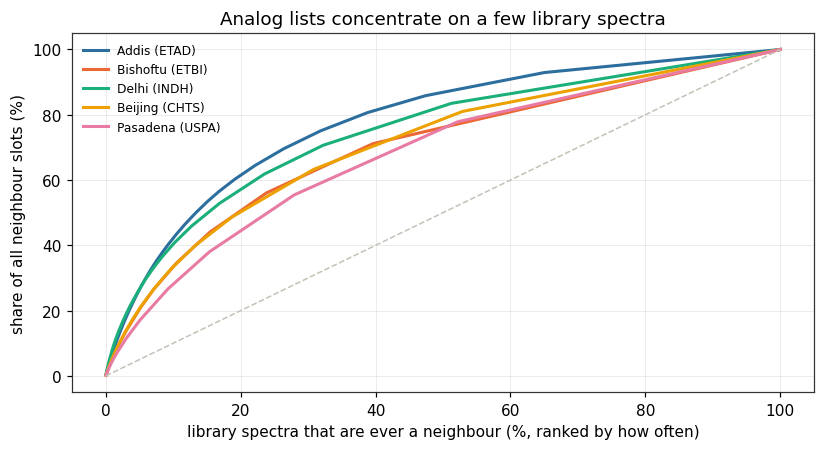

In [6]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
for key, label, colour in zip(TARGETS, TARGETS.values(),
                              ['#2C6E9E', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']):
    counts = np.sort(ss.redundancy(X[key], LIB, k=K)['counts'])[::-1]
    counts = counts[counts > 0]
    ax.plot(np.arange(1, len(counts) + 1) / len(counts) * 100,
            np.cumsum(counts) / counts.sum() * 100, lw=2, color=colour, label=label)
ax.plot([0, 100], [0, 100], ls='--', lw=1, color='#c3c2b7')
ax.set(xlabel='library spectra that are ever a neighbour (%, ranked by how often)',
       ylabel='share of all neighbour slots (%)',
       title='Analog lists concentrate on a few library spectra')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS / 'hubness_lorenz.png', dpi=150)
plt.show()

## 4. Where the spectra actually differ

Band-resolved correlation against the library median, per target. The AIRSpec grid
starts at 1425 cm-1, so only windows the grid genuinely covers are reported (the
module enforces 60% coverage rather than silently correlating a sliver).

In [7]:
lib_median = np.median(LIB, axis=0)[None, :]
rows = []
for key, label in TARGETS.items():
    profile = ss.band_profile(X[key], lib_median, WN)
    row = {'target': label,
           'whole_spectrum': round(float(np.median(
               ss.correlation_matrix(X[key], lib_median))), 3)}
    for band, r in profile.items():
        row[band] = round(float(np.median(r)), 3)
    rows.append(row)
bands = pd.DataFrame(rows)
bands.to_csv(OUT / 'band_correlations.csv', index=False)
display(bands)

band_cols = [c for c in bands.columns if c not in ('target', 'whole_spectrum')]
worst = bands.set_index('target')[band_cols].idxmin(axis=1)
print('\nweakest-agreeing band per target:')
for target, band in worst.items():
    print(f'  {target:<18} {band} '
          f'(r={bands.set_index("target").loc[target, band]:.3f} vs whole-spectrum '
          f'{bands.set_index("target").loc[target, "whole_spectrum"]:.3f})')

,target,whole_spectrum,OH_broad,aliphatic_CH,carbonyl,band_1617
0,Addis (ETAD),0.949,0.981,0.682,0.898,0.781
1,Bishoftu (ETBI),0.976,0.993,0.968,0.930,0.953
2,Delhi (INDH),0.934,0.976,0.878,0.907,0.936
3,Beijing (CHTS),0.953,0.976,0.980,0.927,0.969
4,Pasadena (USPA),0.932,0.974,0.973,0.961,0.967



weakest-agreeing band per target:
  Addis (ETAD)       aliphatic_CH (r=0.682 vs whole-spectrum 0.949)
  Bishoftu (ETBI)    carbonyl (r=0.930 vs whole-spectrum 0.976)
  Delhi (INDH)       aliphatic_CH (r=0.878 vs whole-spectrum 0.934)
  Beijing (CHTS)     carbonyl (r=0.927 vs whole-spectrum 0.953)
  Pasadena (USPA)    carbonyl (r=0.961 vs whole-spectrum 0.932)


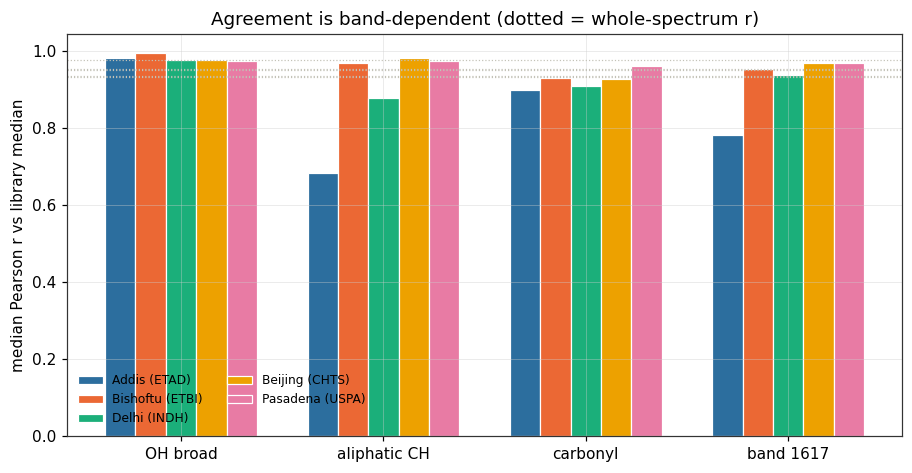

In [8]:
fig, ax = plt.subplots(figsize=(8.4, 4.4))
width = 0.15
xpos = np.arange(len(band_cols))
for i, (key, label, colour) in enumerate(zip(
        TARGETS, TARGETS.values(), ['#2C6E9E', '#eb6834', '#1baf7a', '#eda100', '#e87ba4'])):
    vals = bands.set_index('target').loc[label, band_cols].to_numpy(float)
    ax.bar(xpos + (i - 2) * width, vals, width, color=colour, label=label,
           edgecolor='white', linewidth=0.8)
for i, label in enumerate(TARGETS.values()):
    ax.axhline(bands.set_index('target').loc[label, 'whole_spectrum'],
               color='#c3c2b7', lw=0.8, ls=':')
ax.set_xticks(xpos, [c.replace('_', ' ') for c in band_cols])
ax.set(ylabel='median Pearson r vs library median',
       title='Agreement is band-dependent (dotted = whole-spectrum r)')
ax.legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(PLOTS / 'band_correlations.png', dpi=150)
plt.show()

## 5. Do the metrics agree, and what does fusion give?

Rank the library by Addis-likeness under four independent metrics, then fuse by Borda
count. Spearman agreement between metrics is the honest uncertainty on any single
"top-N analog cohort".

In [9]:
addis = X['addis']
addis_median = np.median(addis, axis=0)[None, :]
metric_scores = {
    'pearson_to_median': -ss.correlation_matrix(LIB, addis_median).ravel(),
    'sam_to_median': ss.spectral_angle(LIB, addis_median).ravel(),
    'sid_to_median': ss.spectral_information_divergence(LIB, addis_median).ravel(),
    'nearest_pearson': -ss.correlation_matrix(LIB, addis).max(axis=1),
}
d_addis = diag['addis']
lib_diag = ss.pca_domain_diagnostics(LIB, addis, n_components=10)
metric_scores['t2_to_addis_centre'] = np.abs(
    lib_diag['library_T2'] - np.median(lib_diag['T2']))

ranks = {name: np.argsort(np.argsort(v)) for name, v in metric_scores.items()}
agreement = pd.DataFrame(
    {a: {b: round(float(np.corrcoef(ranks[a], ranks[b])[0, 1]), 3) for b in ranks}
     for a in ranks})
display(agreement)

fused = ss.rank_fusion(metric_scores)
fusion_rank = np.argsort(fused)
top500 = fusion_rank[:500]
print(f'\nfused top-500 spans {len(np.unique(lib_site[top500]))} IMPROVE sites; '
      f'most common: {pd.Series(lib_site[top500]).value_counts().head(3).to_dict()}')

pairs = [(a, b) for i, a in enumerate(ranks) for b in list(ranks)[i + 1:]]
spread = [agreement.loc[a, b] for a, b in pairs]
print(f'pairwise rank agreement: median rho {np.median(spread):.2f}, '
      f'range {min(spread):.2f} to {max(spread):.2f}')

pd.DataFrame({
    'analysis_id': lib_id, 'site': lib_site, 'fused_rank_score': fused,
    **{f'rank_{k}': v for k, v in ranks.items()},
}).sort_values('fused_rank_score').to_csv(OUT / 'library_ranked_addis.csv', index=False)

,pearson_to_median,sam_to_median,sid_to_median,nearest_pearson,t2_to_addis_centre
pearson_to_median,1.000,0.990,0.903,0.693,-0.383
sam_to_median,0.990,1.000,0.927,0.632,-0.365
sid_to_median,0.903,0.927,1.000,0.537,-0.306
nearest_pearson,0.693,0.632,0.537,1.000,-0.195
t2_to_addis_centre,-0.383,-0.365,-0.306,-0.195,1.000



fused top-500 spans 112 IMPROVE sites; most common: {'PUSO1': 32, 'BIRM1': 24, 'NOGA1': 24}
pairwise rank agreement: median rho 0.58, range -0.38 to 0.99


## 6. Nearest analogs per filter, not per cohort

The per-filter view LOCAL actually uses: for each target filter, its top-K library
neighbours and how similar they are. The spread of neighbour similarity across a
target's filters is a per-filter applicability statistic that travels with every
prediction.

In [10]:
rows = []
for key, label in TARGETS.items():
    idx, sc = ss.nearest_analogs(X[key], LIB, k=K)
    rows.append({
        'target': label,
        'median_top1_r': round(float(np.median(sc[:, 0])), 4),
        f'median_top{K}_mean_r': round(float(np.median(sc.mean(axis=1))), 4),
        'worst_filter_top1_r': round(float(sc[:, 0].min()), 4),
        'distinct_sites_in_neighbourhoods': int(len(np.unique(lib_site[idx.ravel()]))),
        'dominant_neighbour_site': pd.Series(lib_site[idx.ravel()]).value_counts().index[0],
    })
neighbours = pd.DataFrame(rows)
neighbours.to_csv(OUT / 'nearest_analogs.csv', index=False)
display(neighbours)

,target,median_top1_r,median_top50_mean_r,worst_filter_top1_r,distinct_sites_in_neighbourhoods,dominant_neighbour_site
0,Addis (ETAD),0.9939,0.9875,0.7218,158,PHOE5
1,Bishoftu (ETBI),0.9988,0.9972,0.9904,112,BADL1
2,Delhi (INDH),0.9964,0.9927,0.9282,157,BIRM1
3,Beijing (CHTS),0.9986,0.9969,0.9768,160,BOND1
4,Pasadena (USPA),0.9966,0.9930,0.9453,161,STAR1


## Takeaways

1. **Report T2 and Q separately.** They flag different filters, and "inside the
   Mahalanobis domain" was always a statement about one of the two axes only.
2. **Report neighbourhood redundancy, not neighbour count.** Distinct neighbours per
   slot is comparable across targets; "share of the library reached" is bounded by
   filter count and will mislead. Addis is the most redundant of the five, and the
   per-filter mutual-analog count is a reliability flag that travels with a prediction.
   Negative result worth keeping: the standard equal-k mutual-NN test is vacuous at
   this target size and has to be selectivity-matched before it means anything.
3. **Quote band-resolved similarity, not one r.** The windows where a target tracks the
   library and the window where it separates are different facts, and the separation
   sits where the Ethiopian marker band lives.
4. **Metric choice is a real degree of freedom.** Where rank agreement between metrics
   is weak, any single top-N cohort is one arbitrary choice among many; fusion plus the
   agreement spread is the honest version.

Scope: this is spectral geometry only. Nothing here fits a calibration or claims a
chemical identification, and a library neighbour is a spectral analog, not a
composition match. The pool is lot-248/251 IMPROVE, so "the library" means that
archive, not all FTIR ever measured.